<Figure size 1400x800 with 0 Axes>

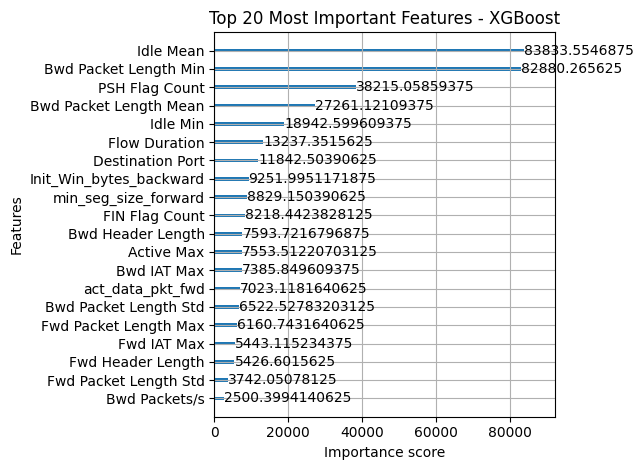


Top 10 Most Important Features:
                feature   importance
              Idle Mean 83833.554688
  Bwd Packet Length Min 82880.265625
         PSH Flag Count 38215.058594
 Bwd Packet Length Mean 27261.121094
               Idle Min 18942.599609
          Flow Duration 13237.351562
       Destination Port 11842.503906
Init_Win_bytes_backward  9251.995117
   min_seg_size_forward  8829.150391
         FIN Flag Count  8218.442383

Top 10 Most Important Features (%):
                feature  importance_pct
              Idle Mean           21.96
  Bwd Packet Length Min           21.71
         PSH Flag Count           10.01
 Bwd Packet Length Mean            7.14
               Idle Min            4.96
          Flow Duration            3.47
       Destination Port            3.10
Init_Win_bytes_backward            2.42
   min_seg_size_forward            2.31
         FIN Flag Count            2.15


In [6]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_importance

# Load model
model = XGBClassifier()
model.load_model('../models/best_model.json')

# Load feature names
df_clean = pd.read_csv('../data/cicids_clean.csv')
feature_cols = [col for col in df_clean.columns if col not in ['Attack Type', 'label']]

# Set feature names in model
model.get_booster().feature_names = feature_cols

# Plot top 20 most important features
plt.figure(figsize=(14, 8))
plot_importance(model, max_num_features=20, importance_type='gain')
plt.title('Top 20 Most Important Features - XGBoost')
plt.tight_layout()
plt.show()

# Get feature importance as DataFrame
importance_dict = model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))
# Normalize to percentage
importance_df['importance_pct'] = (
    importance_df['importance'] / importance_df['importance'].sum() * 100
).round(2)

print("\nTop 10 Most Important Features (%):")
print(importance_df.head(10)[['feature', 'importance_pct']].to_string(index=False))

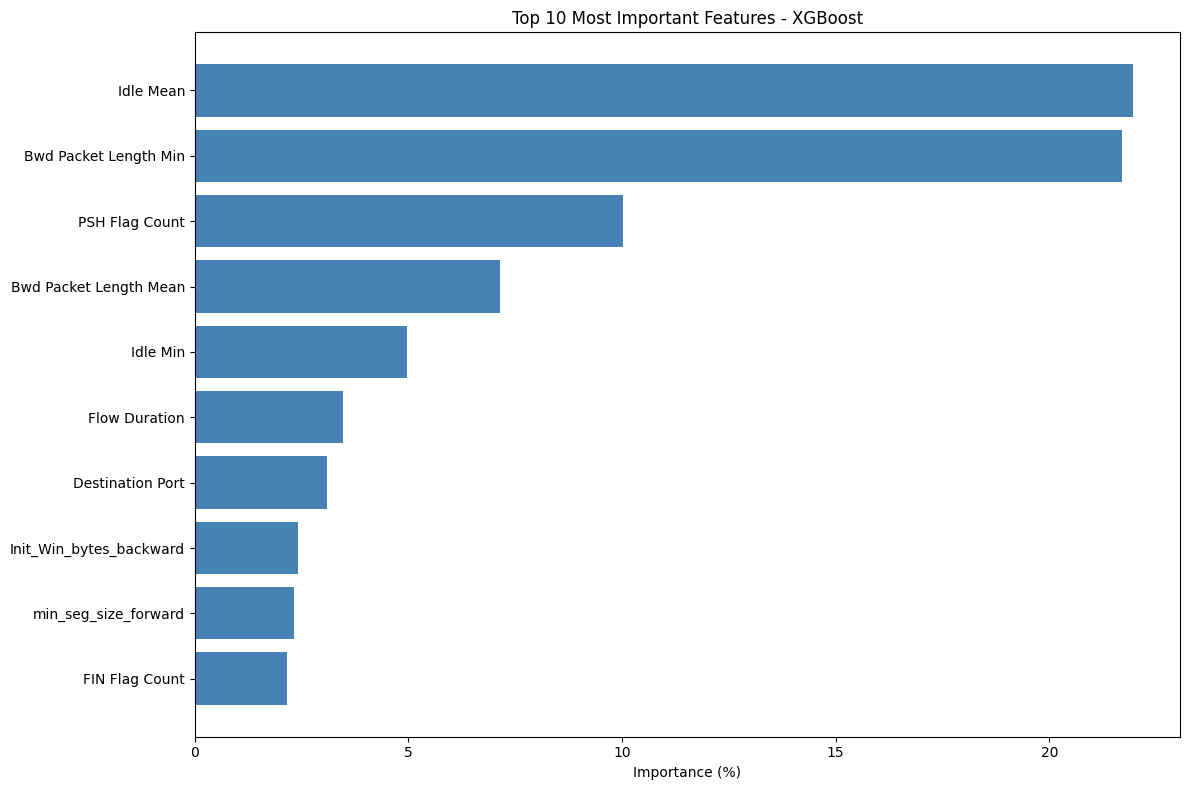

In [7]:
#Visualize top 10 features as percentage
plt.figure(figsize=(12, 8))
plt.barh(
    importance_df.head(10)['feature'][::-1],
    importance_df.head(10)['importance_pct'][::-1],
    color='steelblue'
)
plt.xlabel('Importance (%)')
plt.title('Top 10 Most Important Features - XGBoost')
plt.tight_layout()
plt.show()